## Import Libraries 

In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Data Collection

In [175]:
df = pd.read_csv(r"E:\ML\data\heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [176]:
df.shape

(1025, 14)

## Data Preprocessing

In [98]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## Feature Selection

In [99]:
X = df.drop("target", axis=1)
y = df["target"]

## Data Spliting 

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## Apply Scaling & Pca Method Also Model Selection

In [164]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.98)),
    ('model', SVC(
        C=10,
        kernel='rbf',
        gamma='scale'
    ))
])
# Train model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.98)),
                ('model', SVC(C=10))])

## Hyperparameter Tunning with Random Search CV

In [165]:
param_dist = {
    'model__C': [2, 5, 10],
    'model__gamma': ['scale']
}

random_search = RandomizedSearchCV(
    pipeline,
    param_dist,
    n_iter=8,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

C:\Users\DIKSHA\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=8. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('pca', PCA(n_components=0.98)),
                                             ('model', SVC(C=10))]),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'model__C': [2, 5, 10],
                                        'model__gamma': ['scale']},
                   random_state=42, scoring='accuracy')

In [166]:
best_model = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'model__gamma': 'scale', 'model__C': 10}


In [167]:
train_pred = best_model.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, train_pred))

Training Accuracy: 0.99860529986053


In [168]:
test_pred = best_model.predict(X_test)
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

Testing Accuracy: 0.9707792207792207


In [169]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       150
           1       0.98      0.96      0.97       158

    accuracy                           0.97       308
   macro avg       0.97      0.97      0.97       308
weighted avg       0.97      0.97      0.97       308



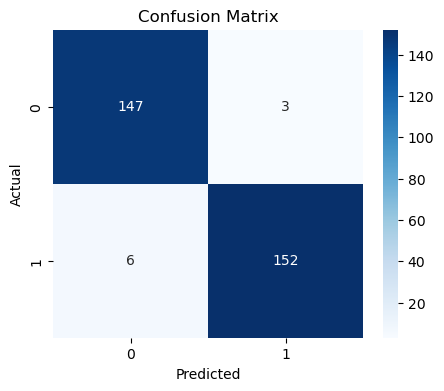

In [170]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()